# Coursework 3: Regression Models
CIVE70122

## 1. Introduction

In this coursework, your task is to develop both a <b>linear regression model</b> and a <b>logistic regression model</b> using the <b>CO₂ emission dataset</b>, which is the same dataset you analysed in last week’s coursework. You will use the most important feature as the input variable. Your objective is to explore how well this feature can predict CO₂ emissions through regression modelling.

For the <b>linear regression model</b>, you will develop the model to predict continuous CO₂ emission values. You should assess its accuracy and reliability using the techniques discussed in this week’s lecture, such as the coefficient of determination (CoD), linear regression between observed and predicted values (R²), etc.. These evaluations will help you determine how well the model fits the data and whether any patterns in the residuals indicate potential improvements.

For the <b>logistic regression model</b>, you will classify CO₂ emissions into two categories—low or high—based on <b>a threshold that you must define</b>. Evaluate your model’s performance using classification metrics such as accuracy, precision, recall, and the confusion matrix, ensuring a critical discussion on its reliability.

## 2. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
import numpy as np
import warnings

# Filter out all warning messages
warnings.filterwarnings('ignore')

# Random seed for reproducibility
np.random.seed(0)

# Load the data from the CSV file
df = pd.read_csv('FULLjapanese.csv')

# Display the summary statistics of the data
df.describe()

,Engine Size(L),Cylinders,CO2 Emissions(g/km),demand_target,revenue_target,car_price
count,1239.000000,1239.000000,1239.000000,1239.000000,1.239000e+03,1239.000000
mean,2.765940,4.915254,220.673123,3465.235674,1.229087e+08,37357.949960
std,1.042204,1.271059,55.267046,974.695115,2.196836e+07,8041.748106
min,1.200000,3.000000,104.000000,641.000000,4.028685e+07,26100.000000
25%,2.000000,4.000000,180.000000,2851.500000,1.100600e+08,30600.000000
50%,2.500000,4.000000,211.000000,3557.000000,1.273266e+08,34100.000000
75%,3.500000,6.000000,255.000000,4189.500000,1.382072e+08,42650.000000
max,5.700000,8.000000,398.000000,5705.000000,1.787272e+08,66350.000000


## 3. Linear Regression Model

### 3.1 Extract and Plot Model Inputs and Outputs

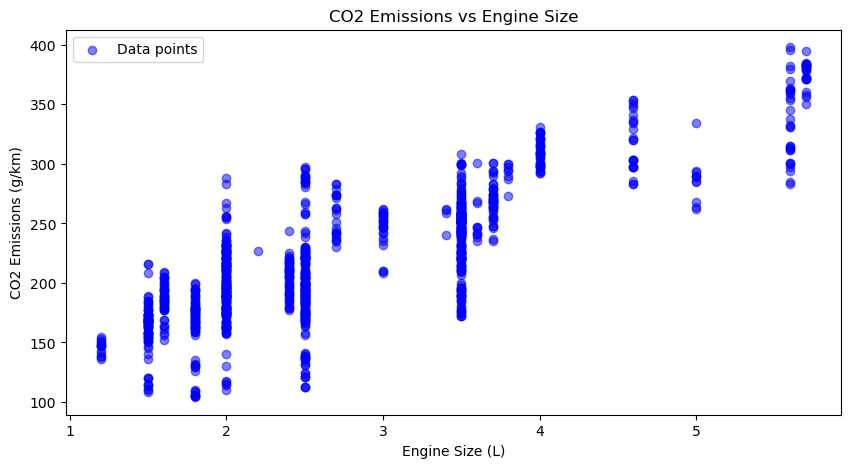

In [2]:
# Please insert the feature (x) and the target variable (y_obs)
x = df[['Engine Size(L)']]  # Double brackets to ensure x is a DataFrame (2D array)
y_obs = df['CO2 Emissions(g/km)']

# Plot the data points
plt.figure(figsize=(10,5))
plt.scatter(x, y_obs, color='blue', label='Data points', alpha=0.5)
plt.title('CO2 Emissions vs Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()
plt.show()

### 3.2 Model Development

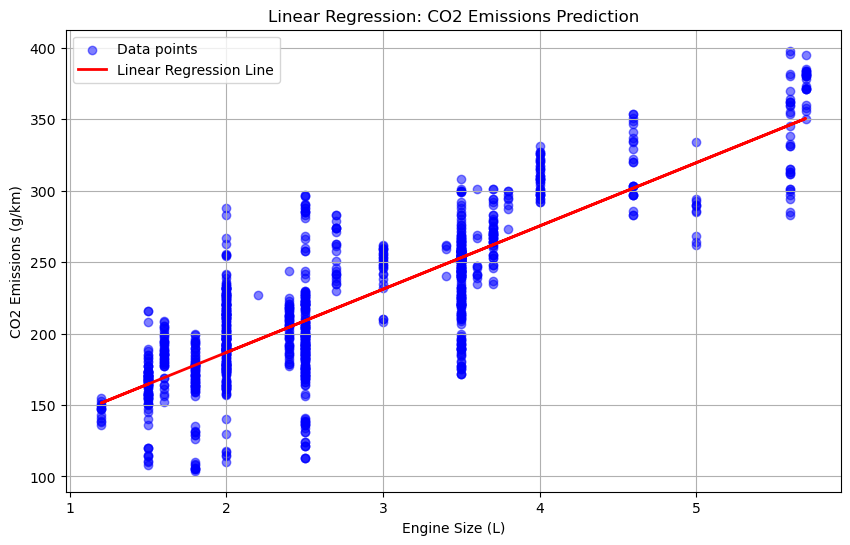

In [3]:
# Linear regression using scikit-learn
lin_model = LinearRegression()
lin_model.fit(x.values.reshape(-1, 1), y_obs)
y_pred = lin_model.predict(x.values.reshape(-1, 1))

# Plotting the linear regression line
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, color='blue', label='Data points', alpha=0.5)
plt.plot(x, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.title('Linear Regression: CO2 Emissions Prediction')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend()
plt.grid(True)
plt.show()

### 3.3 Coefficient of determination

In [4]:
# Calculate the mean of the observed values as y_obs_mean
y_obs_mean = np.mean(y_obs)

# sum of squared differences between observed and predicted values (Residual Sum of Squares)
ss_res = np.sum((y_obs - y_pred) ** 2)

# sum of squared differences between observed and y_obs_mean (Total Sum of Squares)
ss_mean = np.sum((y_obs - y_obs_mean) ** 2)

# Calculate the coefficient of determination (CoD)
CoD = 1 - (ss_res / ss_mean)

print(f"Coefficient of Determination (CoD): {CoD:.3f}")

Coefficient of Determination (CoD): 0.697


### 3.4 Residual Plot

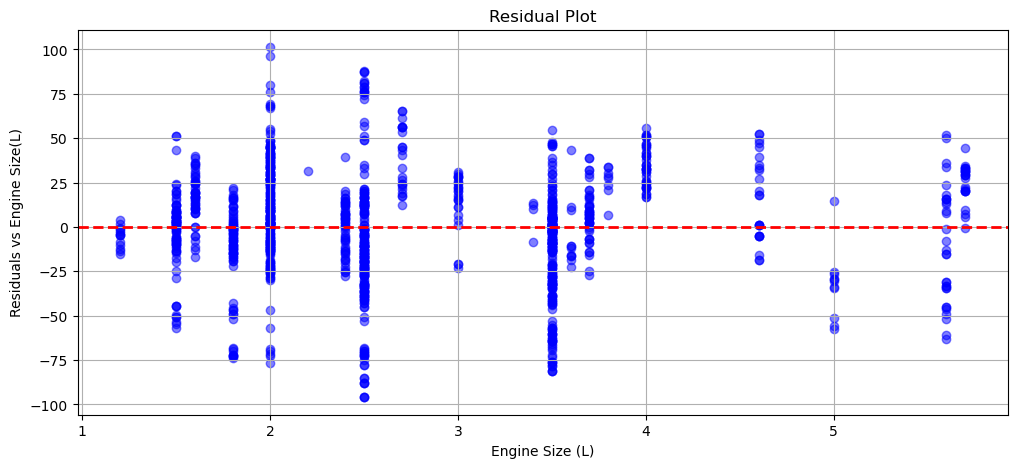

In [5]:
# Plot the residuals against the x values
residuals = y_obs - y_pred

plt.figure(figsize=(12, 5))
plt.scatter(x, residuals, color='blue', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Engine Size (L)')
plt.ylabel('Residuals vs Engine Size(L)')
plt.grid(True)
plt.show()

### 3.5 Linear Regression between Observed and Predicted Values

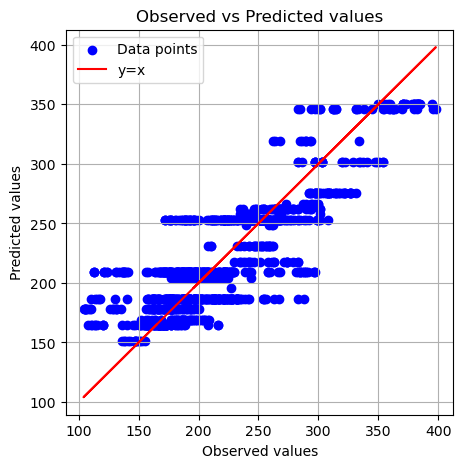

In [6]:
# Plot y_pred against y_obs and include the line y=x
plt.figure(figsize=(5, 5))
plt.scatter(y_obs, y_pred, color='blue', label='Data points')
plt.plot(y_obs, y_obs, color='red', label='y=x')
plt.xlabel('Observed values')
plt.ylabel('Predicted values')
plt.title('Observed vs Predicted values')
plt.legend()
plt.grid(True)
plt.show()

### 3.6 R-squared Value

In [7]:
# Calculate the R^2 value using the r2_score function
r2 = r2_score(y_obs, y_pred)
print(f"R^2 value: {r2:.3f}")

# Calculate the slope and intercept of the linear regression line
slope = lin_model.coef_[0]
intercept = lin_model.intercept_
print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")

R^2 value: 0.697
Slope: 44.259
Intercept: 98.255


## 4. Logistic Regression

### 4.1 Model Development

Threshold: 220.67


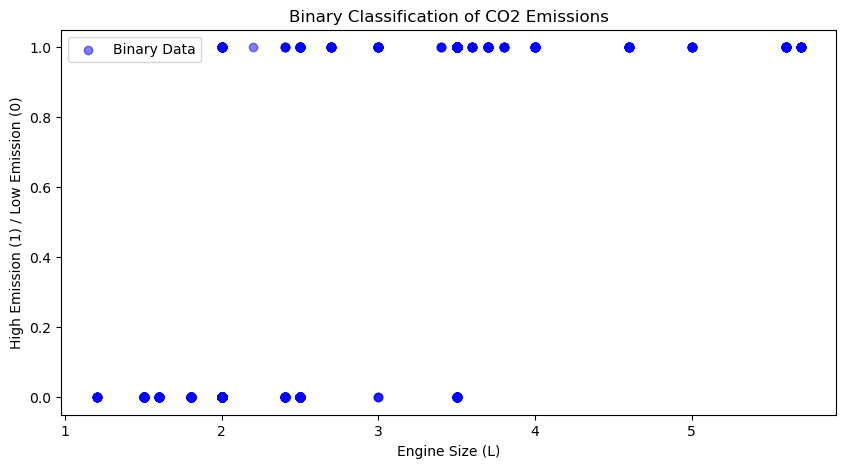

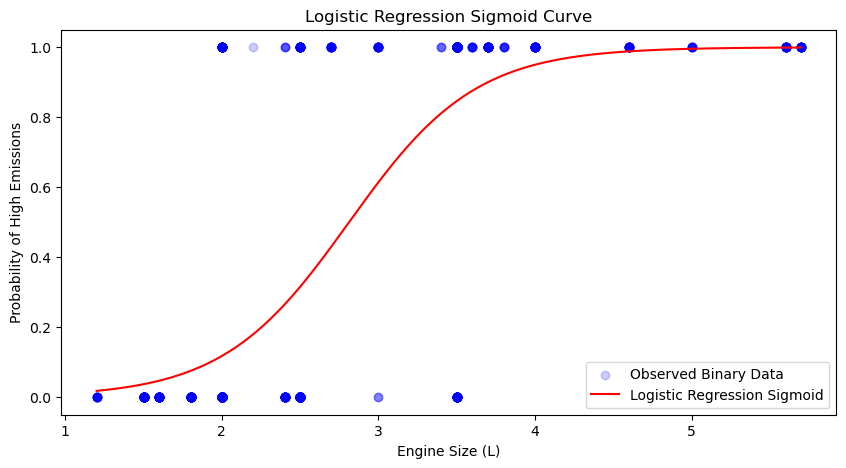

In [8]:
# Extract the input and output data for logistic regression
x = df[['Engine Size(L)']]
y_obs = df['CO2 Emissions(g/km)']

# Calculate the threshold value as the mean of the observed values
threshold = np.mean(y_obs)
print(f"Threshold: {threshold:.2f}")

# Binarise the output values 
y_bin = y_obs > threshold

# Logistic regression using scikit-learn
log_model = LogisticRegression()
log_model.fit(x, y_bin)
y_values = log_model.predict(x)

# Plot the binary values
plt.figure(figsize=(10, 5))
plt.scatter(x, y_bin, color='blue', label='Binary Data', alpha=0.5)
plt.title('Binary Classification of CO2 Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('High Emission (1) / Low Emission (0)')
plt.legend()
plt.show()

# Plot the logistic regression line as a sigmoid function
x_values = np.linspace(x.min(), x.max(), 300).reshape(-1, 1)
y_values_bin = log_model.predict_proba(x_values)[:, 1] # Probability of class 1

plt.figure(figsize=(10, 5))
plt.scatter(x, y_bin, color='blue', label='Observed Binary Data', alpha=0.2)
plt.plot(x_values, y_values_bin, color='red', label='Logistic Regression Sigmoid')
plt.title('Logistic Regression Sigmoid Curve')
plt.xlabel('Engine Size (L)')
plt.ylabel('Probability of High Emissions')
plt.legend()
plt.show()

### 4.2 Confusion Matrix

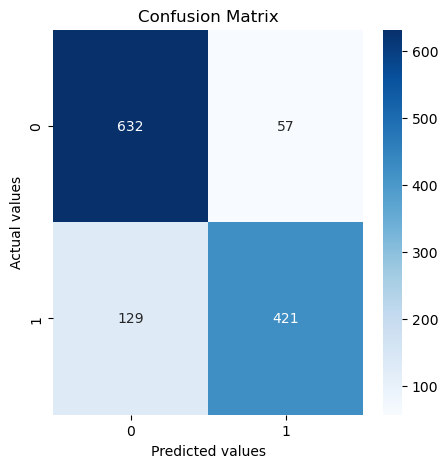

In [9]:
# Confusion matrix of the logistic regression model
from sklearn.metrics import confusion_matrix
# import accuracy, precision, sensitivity (recall), specificity and F1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# import seaborn as sns
import seaborn as sns

conf_matrix = confusion_matrix(y_bin, y_values)
plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.title('Confusion Matrix')
plt.show()

### 4.3 Calculations of accuracy, precision, sensitivity (recall), specificity and F1 score

In [10]:
# Calculate the accuracy, precision, sensitivity (recall), specificity and F1 score
accuracy = accuracy_score(y_bin, y_values)
precision = precision_score(y_bin, y_values)
sensitivity = recall_score(y_bin, y_values)
specificity = conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])
f1_score = f1_score(y_bin, y_values)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1_score:.3f}")

Accuracy: 0.850
Precision: 0.881
Sensitivity: 0.765
Specificity: 0.917
F1 Score: 0.819


### CONCLUSION

I decided to go with Engine Size as our input variable. Engine Size ($R^2 \approx 0.76$) is a strong predictor but not perfect. It leaves us with interesting errors to analyze like seeing how two engines of the same size might pollute differently because of different fuel types.

If we used Fuel Consumption, the model would be nearly perfect ($R^2 \approx 0.99$) because burning fuel is essentially the same thing as creating emissions. We would have almost zero errors to analyze, making the 'discussion' section really hard to write.

It makes more engineering sense : We should be trying to predict emissions based on how the car is designed (its engine size). Predicting emissions from fuel consumption is a bit circular since they are basically the same measurement. Engine size lets us model the cause and effect relationship better.